In [35]:
import pandas as pd
df_final = pd.read_csv('/content/drive/MyDrive/projet11/df_final.csv',index_col="Country Code")
df_final.head()

,Zone,Disponibilité de protéines en quantité (g/personne/jour),Exportations - Quantité,Importations - Quantité,Production,Population_2017,PIB_hab_2017,pop_urb_2017,User_net_2017,Score_commerce_2019
Country Code,,,,,,,,,,
AFG,Afghanistan,0.54,0.0,29.0,28.0,36296.113,525.469771,24.835282,13.500000,99.0
ZAF,Afrique du Sud,14.11,63.0,514.0,1667.0,57009.756,6618.335083,63.331108,56.167400,99.0
ALB,Albanie,6.26,0.0,38.0,13.0,2884.169,5006.360130,55.980276,62.400002,99.0
DZA,Algérie,1.97,0.0,2.0,275.0,41389.189,4554.667540,71.322791,47.691101,99.0
DEU,Allemagne,7.96,646.0,842.0,1514.0,82658.409,45553.934150,80.984254,84.394154,99.0


In [36]:
#sectionner les variables numériques
X = df_final.select_dtypes(include='number')

In [37]:
corr = X.corr()

# Standarisation (Centage et Réduction)

In [38]:
from sklearn.preprocessing import StandardScaler
# On instancie notre scaler : Crée l’outil de standardisation.
scaler = StandardScaler()
# On le fit :créer l outil de standarisation  ; calcule la moyenne et l ecart type de chaque colonne
#scaler.fit(X)
# On l'entraine :  appliquer la formule z=x−xˉ/s
#X_scaled = scaler.transform(X)
# On peut faire les 2 opérations en une ligne :
X_scaled = scaler.fit_transform(X)
# On le transforme en DataFrame :  Transforme le résultat en tableau pandas.
X_scaled = pd.DataFrame(X_scaled,columns=X.columns,index=X.index)
# On peut appliquer la méthode .describe() et .round() : Affiche les statistiques des données centrées-réduites.
X_scaled.describe().round(2)

,Disponibilité de protéines en quantité (g/personne/jour),Exportations - Quantité,Importations - Quantité,Production,Population_2017,PIB_hab_2017,pop_urb_2017,User_net_2017,Score_commerce_2019
count,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.27,-0.23,-0.48,-0.29,-0.28,-0.69,-2.11,-1.97,-6.72
25%,-0.89,-0.23,-0.46,-0.28,-0.26,-0.59,-0.62,-0.89,0.24
50%,-0.11,-0.23,-0.39,-0.26,-0.22,-0.38,0.08,0.13,0.24
75%,0.58,-0.20,-0.05,-0.14,-0.08,0.10,0.64,0.76,0.24
max,3.71,9.02,5.29,8.59,9.03,5.48,2.06,1.76,0.32


In [39]:
X_scaled.head()

,Disponibilité de protéines en quantité (g/personne/jour),Exportations - Quantité,Importations - Quantité,Production,Population_2017,PIB_hab_2017,pop_urb_2017,User_net_2017,Score_commerce_2019
Country Code,,,,,,,,,
AFG,-1.177931,-0.227157,-0.321067,-0.275742,-0.042889,-0.688831,-1.672513,-1.594839,0.235218
ZAF,1.250856,-0.089221,2.296542,0.388559,0.092833,-0.346170,0.241574,0.095538,0.235218
ALB,-0.154154,-0.227157,-0.272492,-0.281822,-0.261814,-0.436827,-0.123924,0.342458,0.235218
DZA,-0.921987,-0.227157,-0.466789,-0.175631,-0.009518,-0.462230,0.638936,-0.240272,0.235218
DEU,0.150116,1.187237,4.066801,0.326547,0.260891,1.843554,1.119322,1.213812,0.235218


# ACP

In [40]:
#projeter les données standardisées(les pays) depuis l’espace initial des variables vers un nouvel espace factoriel composé des axes F1, F2, F3,
#X_pca : coordonnées des pays dans l’espace ACP
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

Éboulis des valeurs propres

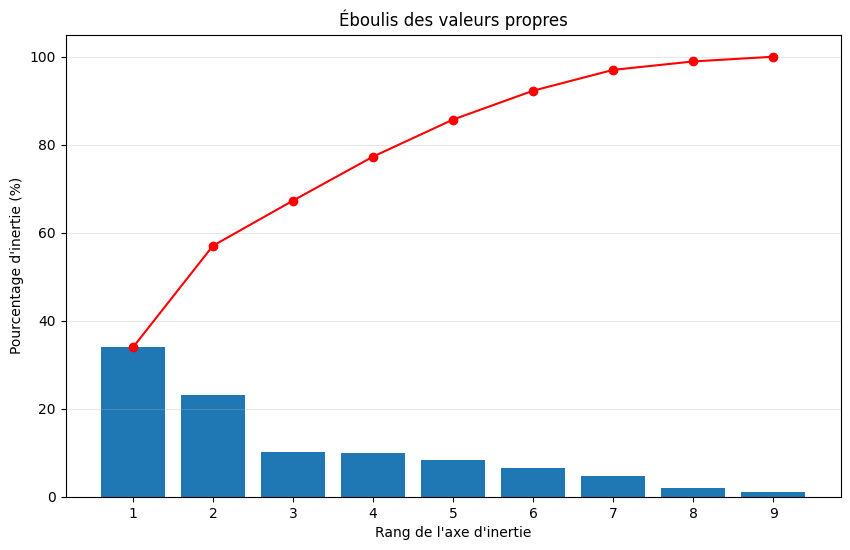

In [41]:
import matplotlib.pyplot as plt
import numpy as np
#le pourcentage d’information expliqué par chaque axe.
# Variance expliquée (%)
scree = pca.explained_variance_ratio_ * 100
# Variance cumulée (%)
scree_cum = np.cumsum(scree)
# Liste des composantes
x_list = range(1, len(scree) + 1)
# Graphique
plt.figure(figsize=(10,6))
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum, c="red", marker="o")
plt.xlabel("Rang de l'axe d'inertie")
plt.ylabel("Pourcentage d'inertie (%)")
plt.title("Éboulis des valeurs propres")
plt.xticks(x_list)
plt.grid(axis='y', alpha=0.3)
plt.show()

On a en bleu la variance de chaque nouvelle composante, et en rouge la variance cumulée.

In [42]:
# Pourcentage d'inertie expliqué par chaque axe
inertie = pca.explained_variance_ratio_ * 100

for i, val in enumerate(inertie):
    print(f"F{i+1} : {val:.2f} %")

F1 : 33.93 %
F2 : 23.11 %
F3 : 10.26 %
F4 : 10.00 %
F5 : 8.43 %
F6 : 6.56 %
F7 : 4.73 %
F8 : 1.91 %
F9 : 1.07 %


In [43]:
#Combien de composantes à analyser
inertie_cumulee = np.cumsum(inertie)
for i, val in enumerate(inertie_cumulee):
    print(f"F1 à F{i+1} : {val:.2f} %")

F1 à F1 : 33.93 %
F1 à F2 : 57.04 %
F1 à F3 : 67.30 %
F1 à F4 : 77.30 %
F1 à F5 : 85.73 %
F1 à F6 : 92.28 %
F1 à F7 : 97.01 %
F1 à F8 : 98.93 %
F1 à F9 : 100.00 %


Pour visualiser les données on va prendre les deux axes F1 F2

# Tableau des composantes principale (Représentation des p variables sous forme numérique dans l'espace factoriel)

La formule de ce calcul nous est donnée par l'attribut components_. Cette variable est généralement nommée pcs :

In [44]:
pcs = pca.components_
#Affichons la même chose mais version pandas :
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8
0,0.398899,0.243215,0.263374,0.214356,0.041814,0.406103,0.450780,0.500933,0.213558
1,-0.061590,0.478020,0.106238,0.614868,0.507433,-0.237556,-0.140945,-0.206751,-0.042687
2,-0.205422,-0.345132,0.331345,-0.092789,0.329478,-0.111084,-0.020130,-0.051892,0.772200
3,-0.253826,-0.273205,0.644388,-0.091422,0.264214,0.146988,0.162229,-0.011140,-0.565227
4,0.339414,0.214005,0.604827,-0.069473,-0.499060,-0.395468,-0.185559,-0.158212,0.058643
5,0.712632,-0.384167,-0.055241,-0.027650,0.387287,-0.021297,-0.408490,0.070418,-0.135971
6,-0.126131,0.202887,0.153045,-0.023080,-0.092241,0.711893,-0.612456,-0.131972,0.105613
7,-0.296898,0.040051,0.042604,0.021767,-0.028084,-0.274385,-0.415403,0.809719,-0.060650
8,-0.057944,-0.531447,0.014767,0.743252,-0.392491,0.075998,-0.035359,-0.021261,0.006080


In [45]:
#arrondir les résultats pour simplifier l'analyse
features = X.columns
pcs.columns = features
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,Disponibilité de protéines en quantité (g/personne/jour),Exportations - Quantité,Importations - Quantité,Production,Population_2017,PIB_hab_2017,pop_urb_2017,User_net_2017,Score_commerce_2019
F1,0.40,0.24,0.26,0.21,0.04,0.41,0.45,0.50,0.21
F2,-0.06,0.48,0.11,0.61,0.51,-0.24,-0.14,-0.21,-0.04
F3,-0.21,-0.35,0.33,-0.09,0.33,-0.11,-0.02,-0.05,0.77
F4,-0.25,-0.27,0.64,-0.09,0.26,0.15,0.16,-0.01,-0.57
F5,0.34,0.21,0.60,-0.07,-0.50,-0.40,-0.19,-0.16,0.06
F6,0.71,-0.38,-0.06,-0.03,0.39,-0.02,-0.41,0.07,-0.14
F7,-0.13,0.20,0.15,-0.02,-0.09,0.71,-0.61,-0.13,0.11
F8,-0.30,0.04,0.04,0.02,-0.03,-0.27,-0.42,0.81,-0.06
F9,-0.06,-0.53,0.01,0.74,-0.39,0.08,-0.04,-0.02,0.01


In [46]:
pcs.T

,F1,F2,F3,F4,F5,F6,F7,F8,F9
Disponibilité de protéines en quantité (g/personne/jour),0.398899,-0.061590,-0.205422,-0.253826,0.339414,0.712632,-0.126131,-0.296898,-0.057944
Exportations - Quantité,0.243215,0.478020,-0.345132,-0.273205,0.214005,-0.384167,0.202887,0.040051,-0.531447
Importations - Quantité,0.263374,0.106238,0.331345,0.644388,0.604827,-0.055241,0.153045,0.042604,0.014767
Production,0.214356,0.614868,-0.092789,-0.091422,-0.069473,-0.027650,-0.023080,0.021767,0.743252
Population_2017,0.041814,0.507433,0.329478,0.264214,-0.499060,0.387287,-0.092241,-0.028084,-0.392491
PIB_hab_2017,0.406103,-0.237556,-0.111084,0.146988,-0.395468,-0.021297,0.711893,-0.274385,0.075998
pop_urb_2017,0.450780,-0.140945,-0.020130,0.162229,-0.185559,-0.408490,-0.612456,-0.415403,-0.035359
User_net_2017,0.500933,-0.206751,-0.051892,-0.011140,-0.158212,0.070418,-0.131972,0.809719,-0.021261
Score_commerce_2019,0.213558,-0.042687,0.772200,-0.565227,0.058643,-0.135971,0.105613,-0.060650,0.006080


Et pour une représentation plus visuelle, comme cela :

<Axes: >

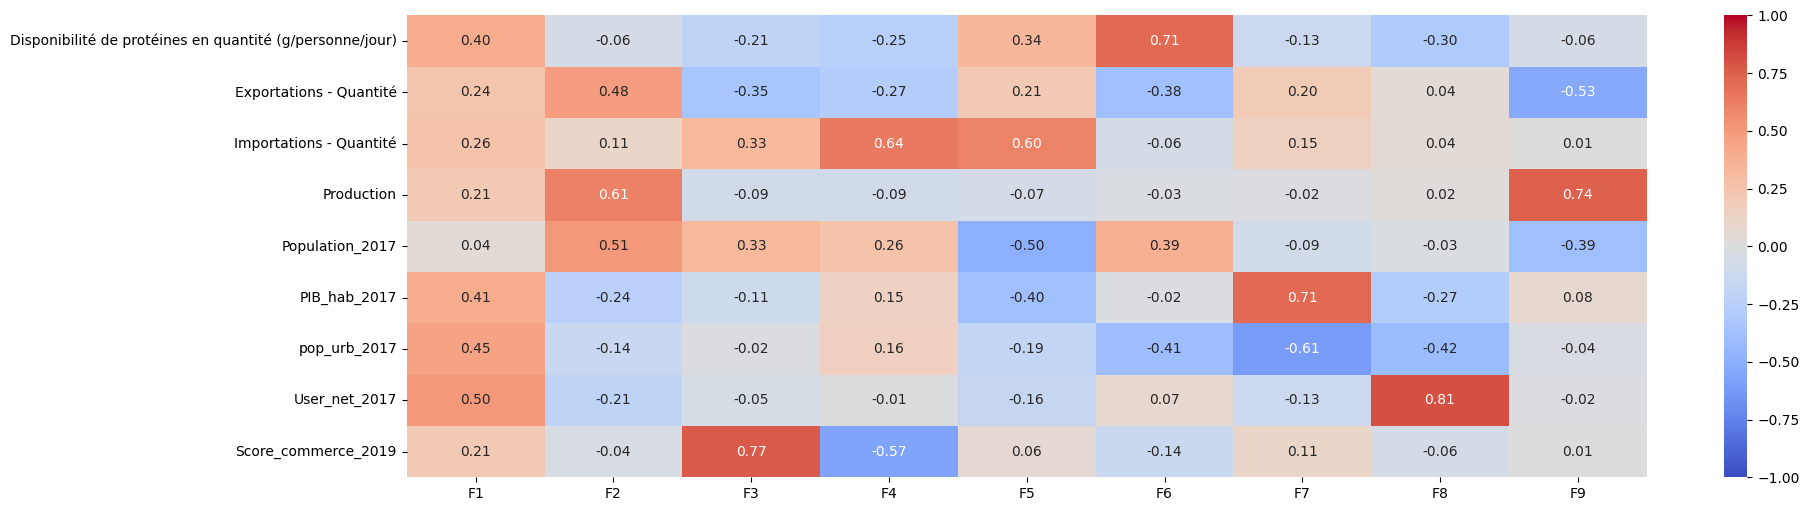

In [47]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

# Cercle de corrélation

In [48]:
x, y = 0,1

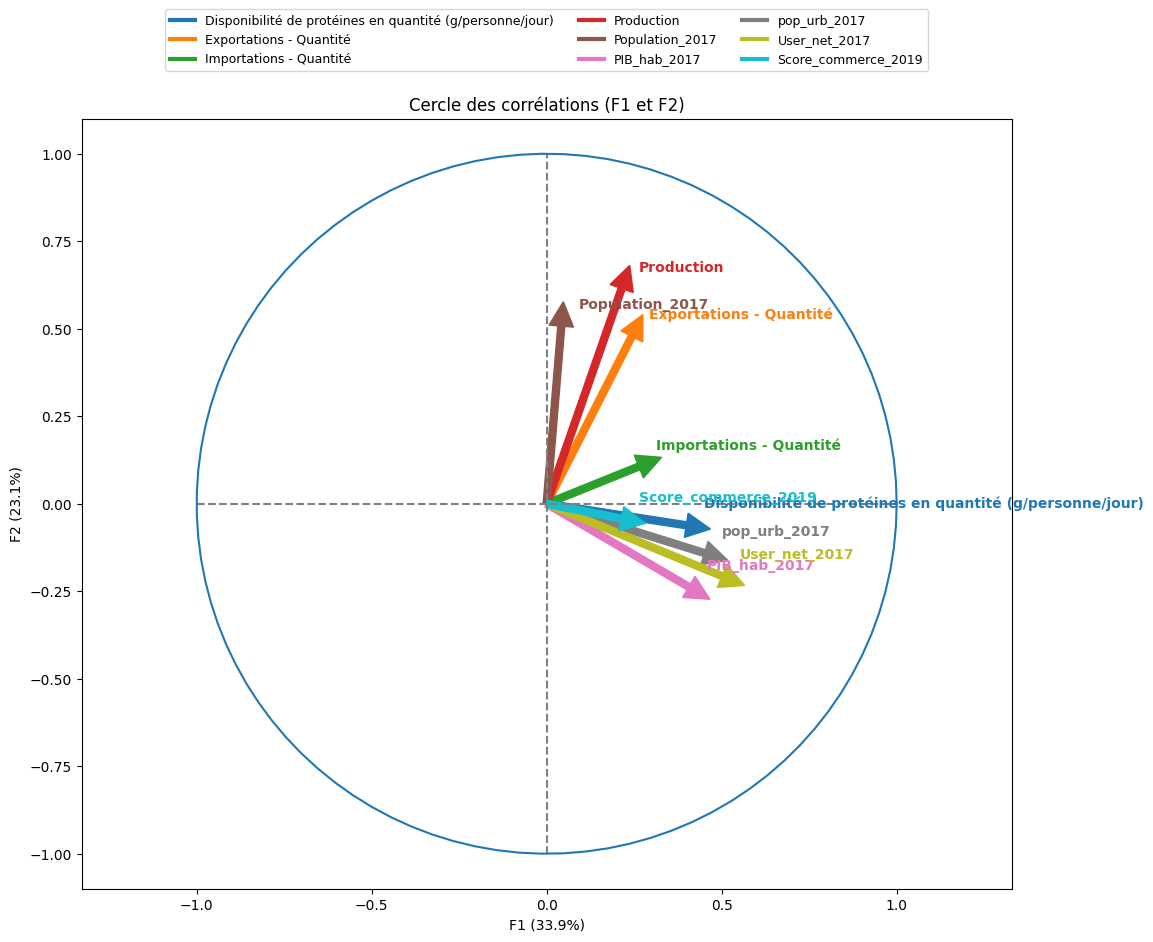

In [49]:
from matplotlib.lines import Line2D
import matplotlib.cm as cm
colors = cm.tab10(np.linspace(0, 1, len(features)))

legend_elements = []

fig, ax = plt.subplots(figsize=(12, 10))

for i in range(pca.components_.shape[1]):

    color = colors[i]

    ax.arrow(
        0,
        0,
        pca.components_[0, i],
        pca.components_[1, i],
        head_width=0.07,
        head_length=0.07,
        width=0.02,
        color=color
    )

    plt.text(
        pca.components_[0, i] + 0.05,
        pca.components_[1, i] + 0.05,
        features[i],
        color=color,
        fontweight='bold'
    )

    # Ajout à la légende
    legend_elements.append(
        Line2D(
            [0], [0],
            color=color,
            lw=3,
            label=features[i]
        )
    )

# Axes
plt.plot([-1, 1], [0, 0], color='grey', ls='--')
plt.plot([0, 0], [-1, 1], color='grey', ls='--')

# Cercle
an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))

# Légende en haut
plt.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    fontsize=9
)

plt.xlabel(f'F{x+1} ({round(100*pca.explained_variance_ratio_[x],1)}%)')
plt.ylabel(f'F{y+1} ({round(100*pca.explained_variance_ratio_[y],1)}%)')
plt.title(f"Cercle des corrélations (F{x+1} et F{y+1})")

plt.axis('equal')
plt.show()

afficher le cercle par une fonction

In [50]:
def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

In [51]:
x_y = (0,1)
x_y

(0, 1)

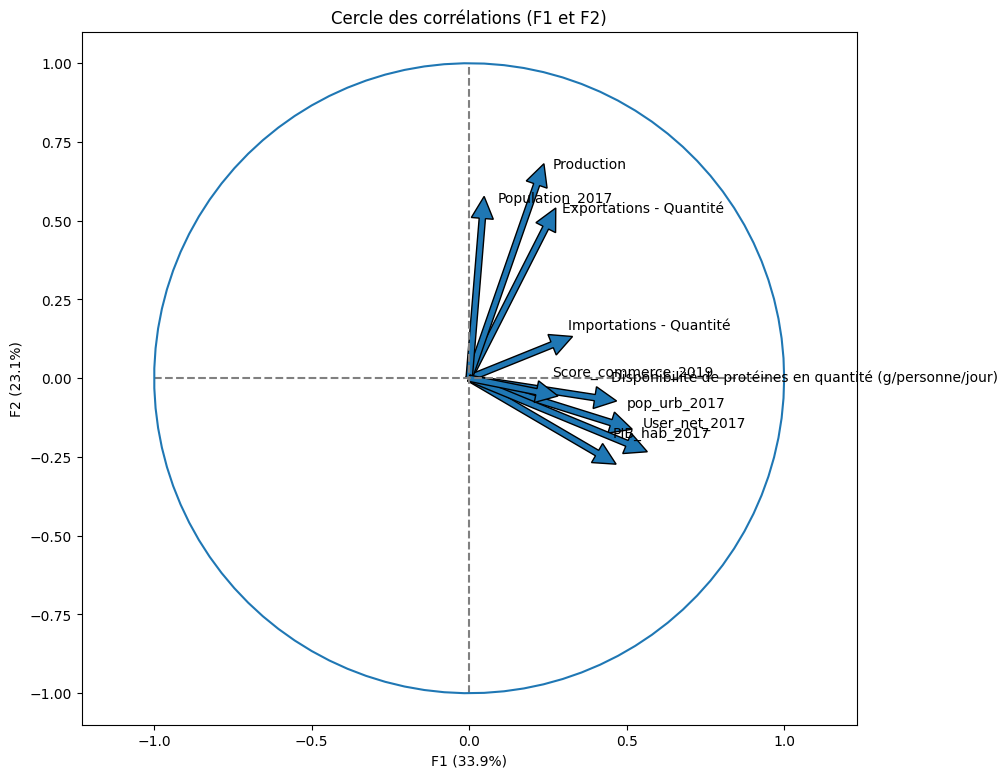

In [52]:
correlation_graph(pca, x_y, features)

# Représenter les indivudus sur le plan factoriel

In [53]:
X_proj = pca.transform(X_scaled)

In [54]:
def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection ACP des pays (sur F{x+1} et F{y+1})")
    plt.show()



/tmp/ipykernel_7679/772787274.py:89: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')


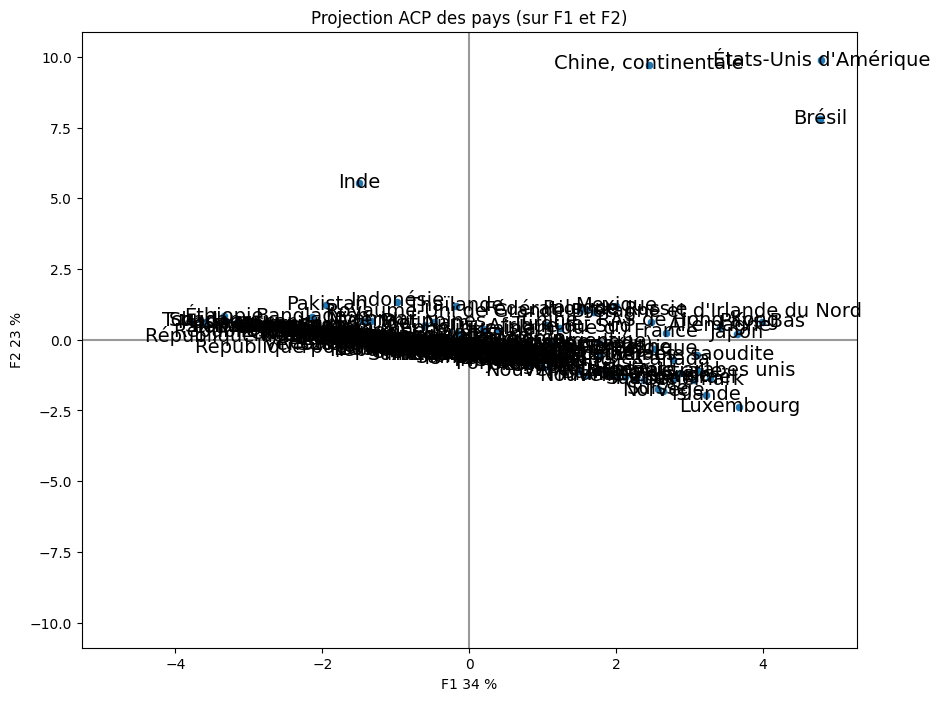

In [55]:
x_y = [0,1]
display_factorial_planes(
    X_proj,
    x_y,
    pca=pca,
    labels=df_final['Zone']
)

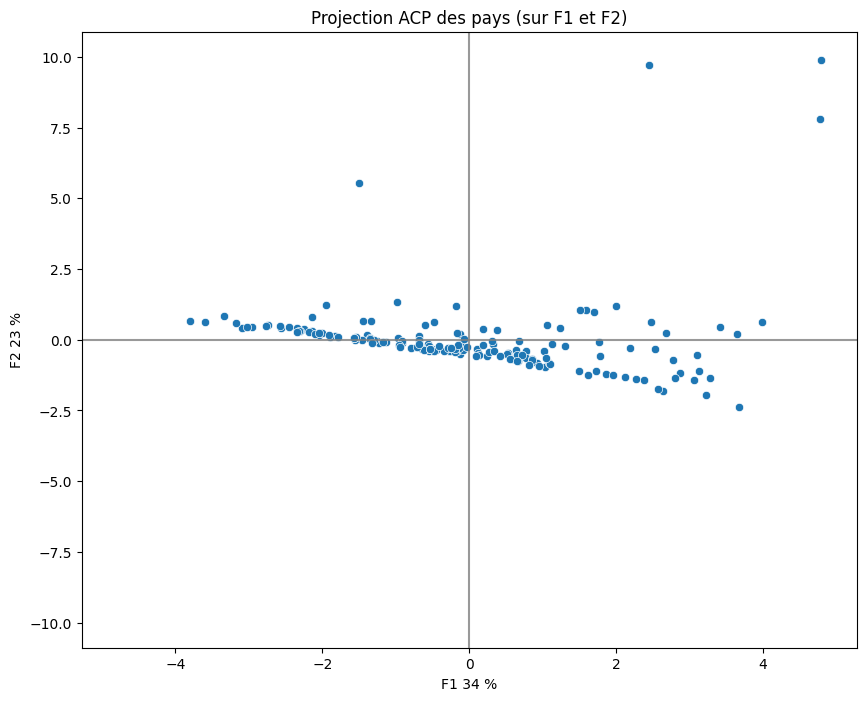

In [56]:
x_y = [0,1]
display_factorial_planes(
    X_proj,
    x_y,
    pca=pca,
    labels=None
)

**enlever les pays trop éloignés**

/tmp/ipykernel_7679/772787274.py:89: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')


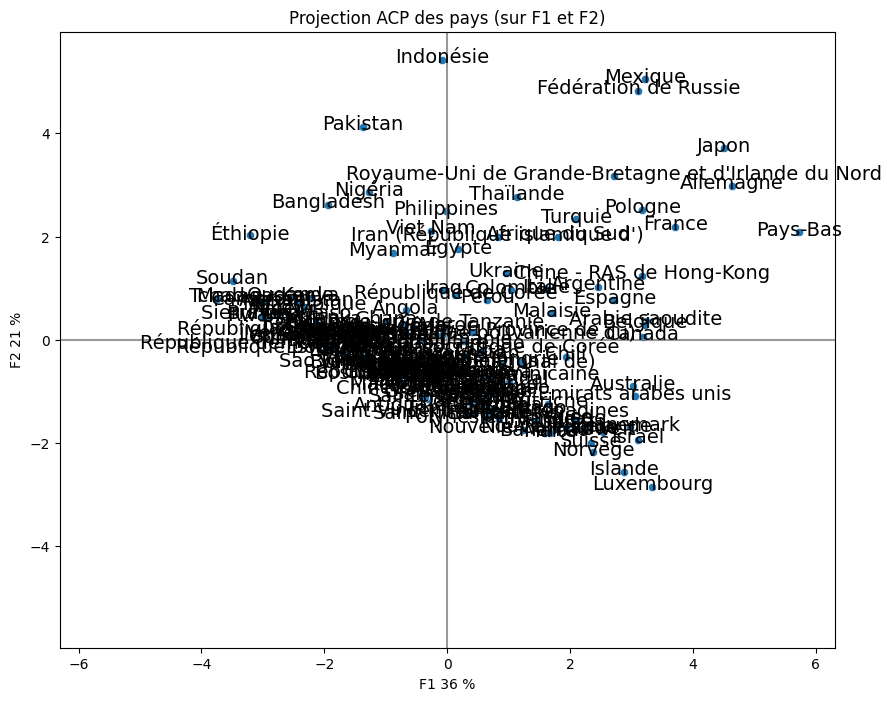

In [57]:
pays_a_supprimer = [
    "Inde",
    "Chine, continentale",
    "États-Unis d'Amérique",
    "Brésil"
]

df_sans_outliers = df_final[
    ~df_final["Zone"].isin(pays_a_supprimer)
].copy()
X_sans_outliers = df_sans_outliers.select_dtypes(include="number")
#refaire la standardisation :
X_scaled_sans_outliers = scaler.fit_transform(X_sans_outliers)

X_scaled_sans_outliers = pd.DataFrame(
    X_scaled_sans_outliers,
    columns=X_sans_outliers.columns,
    index=X_sans_outliers.index
)
#Refaire ACP
pca_sans_outliers = PCA()
X_proj_sans_outliers = pca_sans_outliers.fit_transform(X_scaled_sans_outliers)
#Afficher
x_y = [0, 1]

display_factorial_planes(
    X_proj_sans_outliers,
    x_y,
    pca=pca_sans_outliers,
    labels=df_sans_outliers["Zone"]
)


# K-means

La méthode du coude                                               
Boucle du coude → sert à choisir k (nombre de clusters)

In [58]:
from sklearn import datasets
from sklearn.cluster import KMeans
# Une liste vide pour enregistrer les inerties :
intertia_list = [ ]

# Notre liste de nombres de clusters qu'on veut tester :
k_list = range(1, 10)

# Pour chaque nombre de clusters :
for k in k_list :

    # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k,random_state=42, n_init=50)

    # On entraine
    kmeans.fit(X_scaled)

    # On enregistre l'inertie obtenue :
    intertia_list.append(kmeans.inertia_)

faire un graphique pour constater la "cassure" dans la courbe

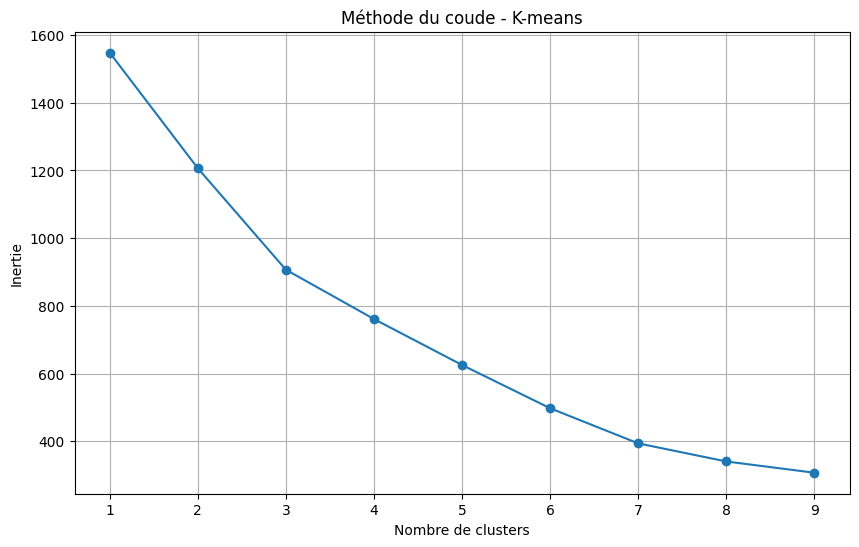

In [59]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(k_list, intertia_list, marker="o")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude - K-means")
plt.grid()
plt.show()

**Créer les Clusters**

In [60]:
# random_state permet d'obtenir les mêmes résultats à chaque exécution
# n_init=10 permet de tester plusieurs initialisations et de garder la meilleure
kmeans = KMeans(n_clusters=4,random_state=42, n_init=50)
kmeans.fit(X_scaled)
kmeans.labels_

array([1, 3, 3, 3, 0, 1, 3, 0, 3, 3, 0, 0, 3, 0, 1, 3, 0, 3, 3, 3, 3, 2,
       3, 1, 3, 1, 3, 1, 1, 0, 3, 0, 3, 3, 2, 3, 3, 3, 3, 3, 3, 1, 0, 3,
       3, 3, 0, 3, 1, 3, 0, 0, 3, 3, 1, 1, 3, 3, 3, 1, 1, 3, 3, 1, 3, 3,
       1, 1, 3, 3, 0, 0, 0, 3, 3, 0, 3, 3, 1, 3, 1, 0, 1, 3, 3, 1, 3, 0,
       3, 1, 3, 1, 3, 1, 0, 3, 3, 1, 0, 1, 3, 1, 1, 1, 1, 1, 1, 0, 3, 0,
       1, 3, 1, 1, 1, 3, 3, 0, 3, 3, 3, 3, 3, 3, 0, 1, 1, 3, 3, 3, 1, 3,
       3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 1, 1, 0, 3, 0, 1, 1, 1, 3, 3, 1, 1,
       3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 1, 1, 3, 0, 3, 2, 1, 1], dtype=int32)

In [61]:
df_final["K_means_cluster"] = kmeans.labels_
df_final["K_means_cluster"].value_counts()

,count
K_means_cluster,
3,91
1,51
0,27
2,3


In [62]:
df_final[df_final["K_means_cluster"] == 0]["Zone"].tolist()

['Allemagne',
 'Arabie saoudite',
 'Australie',
 'Autriche',
 'Bahamas',
 'Belgique',
 'Canada',
 'Chine - RAS de Hong-Kong',
 'Danemark',
 'Espagne',
 'Finlande',
 'France',
 'Irlande',
 'Islande',
 'Israël',
 'Japon',
 'Koweït',
 'Luxembourg',
 'Malte',
 'Mexique',
 'Norvège',
 'Nouvelle-Zélande',
 'Pays-Bas',
 "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord",
 'Suisse',
 'Suède',
 'Émirats arabes unis']

In [63]:
df_final[df_final["K_means_cluster"] == 1]["Zone"].tolist()

['Afghanistan',
 'Angola',
 'Bangladesh',
 'Burkina Faso',
 'Bénin',
 'Cambodge',
 'Cameroun',
 "Côte d'Ivoire",
 'Eswatini',
 'Gambie',
 'Ghana',
 'Guinée',
 'Guinée-Bissau',
 'Haïti',
 'Inde',
 'Indonésie',
 'Kenya',
 'Kiribati',
 'Lesotho',
 'Libéria',
 'Madagascar',
 'Malawi',
 'Mali',
 'Mauritanie',
 'Mongolie',
 'Mozambique',
 'Myanmar',
 'Namibie',
 'Nicaragua',
 'Niger',
 'Nigéria',
 'Népal',
 'Ouganda',
 'Ouzbékistan',
 'Pakistan',
 'Rwanda',
 'République centrafricaine',
 'République démocratique populaire lao',
 'Sierra Leone',
 'Soudan',
 'Sri Lanka',
 'Sénégal',
 'Tadjikistan',
 'Tchad',
 'Timor-Leste',
 'Togo',
 'Vanuatu',
 'Zambie',
 'Zimbabwe',
 'Éthiopie',
 'Îles Salomon']

In [64]:
df_final[df_final["K_means_cluster"] == 2]["Zone"].tolist()

['Brésil', 'Chine, continentale', "États-Unis d'Amérique"]

In [65]:
df_final[df_final["K_means_cluster"] == 3]["Zone"].tolist()

['Afrique du Sud',
 'Albanie',
 'Algérie',
 'Antigua-et-Barbuda',
 'Argentine',
 'Arménie',
 'Azerbaïdjan',
 'Barbade',
 'Belize',
 'Bolivie (État plurinational de)',
 'Bosnie-Herzégovine',
 'Botswana',
 'Bulgarie',
 'Bélarus',
 'Cabo Verde',
 'Chili',
 'Chine - RAS de Macao',
 'Chine, Taiwan Province de',
 'Chypre',
 'Colombie',
 'Congo',
 'Costa Rica',
 'Croatie',
 'Cuba',
 'Djibouti',
 'Dominique',
 'El Salvador',
 'Estonie',
 'Fidji',
 'Fédération de Russie',
 'Gabon',
 'Grenade',
 'Grèce',
 'Guatemala',
 'Guyana',
 'Géorgie',
 'Honduras',
 'Hongrie',
 "Iran (République islamique d')",
 'Iraq',
 'Italie',
 'Jamaïque',
 'Jordanie',
 'Kazakhstan',
 'Kirghizistan',
 'Lettonie',
 'Liban',
 'Lituanie',
 'Macédoine du Nord',
 'Malaisie',
 'Maldives',
 'Maroc',
 'Maurice',
 'Monténégro',
 'Nouvelle-Calédonie',
 'Oman',
 'Panama',
 'Paraguay',
 'Philippines',
 'Pologne',
 'Polynésie française',
 'Portugal',
 'Pérou',
 'Roumanie',
 'République de Corée',
 'République de Moldova',
 'Républiq

In [66]:
df_final_kmeans=df_final.set_index('Zone')
df_final_kmeans=df_final_kmeans.groupby("K_means_cluster").mean()
def color_max(col):
    return [
        "background-color: red; color: white" if val == col.max() else ""
        for val in col
    ]

df_final_kmeans.style.apply(color_max, axis=0)

,Disponibilité de protéines en quantité (g/personne/jour),Exportations - Quantité,Importations - Quantité,Production,Population_2017,PIB_hab_2017,pop_urb_2017,User_net_2017,Score_commerce_2019
K_means_cluster,,,,,,,,,
0,11.840000,191.222222,305.851852,697.444444,26667.784926,45432.995832,82.193791,85.846882,99.148148
1,1.917255,0.450980,20.137255,213.705882,58817.916333,1621.227412,38.871199,21.912867,91.117647
2,13.190000,2830.333333,192.666667,18117.000000,651313.456667,7393.183481,68.830022,60.593945,99.000000
3,8.437692,45.802198,58.868132,414.846154,18627.445132,9511.064521,62.078417,61.855058,98.065934


**visualiser les donnés par l acp**



In [67]:
X_scaled["K_means_cluster"] = kmeans.labels_

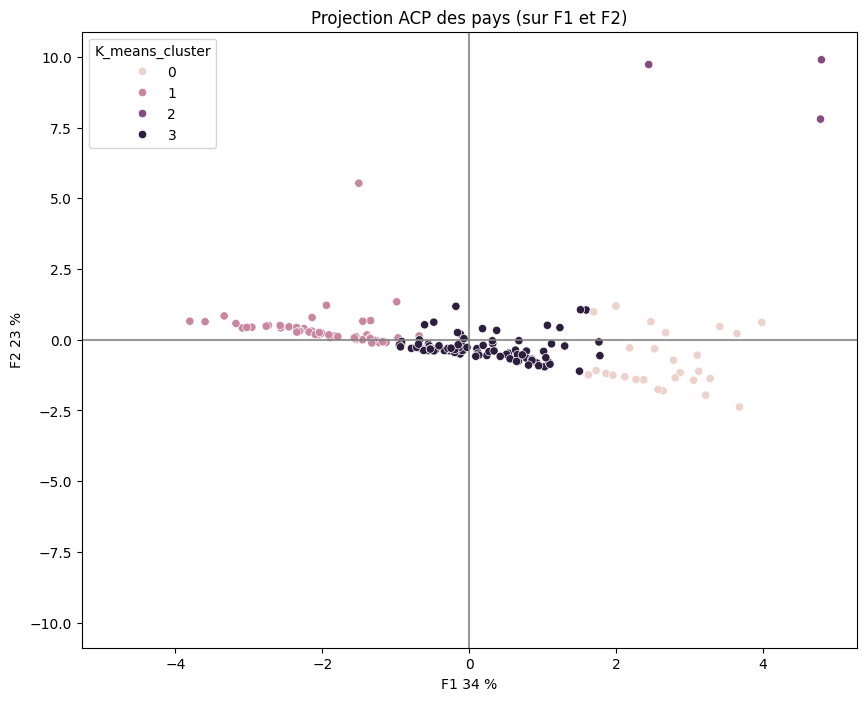

In [68]:
x_y = [0,1]
display_factorial_planes(
    X_proj,
    x_y,
    pca=pca,
     labels=None,
    clusters=X_scaled["K_means_cluster"]
)